# Viz Exploration
Exploratory visualisations for the non-penalty Bayesian model.

## 1. Setup & Load

In [8]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from scipy.stats import poisson as scipy_poisson
import sqlite3
import pickle
import arviz as az

# ── Font setup ───────────────────────────────────────────────
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Regular.ttf')
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Bold.ttf')
plt.rcParams['font.family'] = 'Roboto'

# ── Config ───────────────────────────────────────────────────
LEAGUE      = 'Premier_League'
SEASON      = '2025-2026'
SEASON_KEY  = '2025.10'
MODEL_VER   = 'manual_priors'
DB_PATH     = '/Users/admin/dev/algobetting/infra/data/db/fotmob.db'

BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

TRACE_DIR = os.path.join(
    os.path.dirname(os.path.abspath('')),
    'algo/models/team_strength/non_penalty_bayes/model_traces',
    MODEL_VER
)
# When running from the notebook dir, paths are relative
NOTEBOOK_DIR = os.path.abspath('')
TRACE_DIR = os.path.join(NOTEBOOK_DIR, 'model_traces', MODEL_VER)

trace_path      = os.path.join(TRACE_DIR, f'trace_{LEAGUE}_{SEASON_KEY}.nc')
tm_path         = os.path.join(TRACE_DIR, f'team_mapping_{LEAGUE}_{SEASON_KEY}.pkl')

print(f"Loading trace from: {trace_path}")
trace = az.from_netcdf(trace_path)

with open(tm_path, 'rb') as f:
    tm_list = pickle.load(f)

# team_mapping: list → dict {name: idx}
if isinstance(tm_list, list):
    team_mapping = {name: idx for idx, name in enumerate(tm_list)}
else:
    team_mapping = tm_list

print(f"Teams loaded: {len(team_mapping)}")
print(list(team_mapping.keys()))


Loading trace from: /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/model_traces/manual_priors/trace_Premier_League_2025.10.nc


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/model_traces/manual_priors/trace_Premier_League_2025.10.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import sqlite3

def load_actual_results(db_path: str, league: str, season: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("""
        SELECT
            match_date,
            home.team_name  AS home_team,
            fmd.home_goals,
            away.team_name  AS away_team,
            fmd.away_goals
        FROM matches fmd
            JOIN team_id_mapping home ON home.team_id = fmd.home_team
            JOIN team_id_mapping away ON away.team_id = fmd.away_team
        WHERE
            fmd.league_id = ?
            AND fmd.season  = ?
    """, conn, params=[league, season])
    conn.close()
    df['is_actual'] = True
    return df

df_actual = load_actual_results(DB_PATH, LEAGUE, SEASON)
print(f"Actual matches loaded: {len(df_actual)}")
df_actual.head()


Actual matches loaded: 309


,match_date,home_team,home_goals,away_team,away_goals,is_actual
0,2025-08-23,Brentford,1,Aston Villa,0,True
1,2025-09-13,Fulham,1,Leeds,0,True
2,2025-08-24,Fulham,1,Man United,1,True
3,2025-09-13,Brentford,2,Chelsea,2,True
4,2025-09-27,Chelsea,1,Brighton,3,True


## 2. Performance vs League Average

Bayesian avg-vs-all-opponents rating, Jensen's inequality corrected.

In [ ]:
# Bayesian avg-vs-all ratings
baseline_samples   = trace.posterior['baseline'].values.flatten()
home_adv_samples   = trace.posterior['home_adv'].values.flatten()
all_teams = list(team_mapping.keys())

team_stats = {team: {'goals_for': 0, 'goals_against': 0, 'matches': 0} for team in all_teams}

for home_team in all_teams:
    home_idx = team_mapping[home_team]
    home_att_samples = trace.posterior['att_str'].sel(att_str_dim_0=home_idx).values.flatten()
    home_def_samples = trace.posterior['def_str'].sel(def_str_dim_0=home_idx).values.flatten()

    for away_team in all_teams:
        if home_team == away_team:
            continue
        away_idx = team_mapping[away_team]
        away_att_samples = trace.posterior['att_str'].sel(att_str_dim_0=away_idx).values.flatten()
        away_def_samples = trace.posterior['def_str'].sel(def_str_dim_0=away_idx).values.flatten()

        home_lambda = np.exp(baseline_samples + home_adv_samples + home_att_samples + away_def_samples)
        away_lambda = np.exp(baseline_samples + away_att_samples + home_def_samples)

        home_goals = np.mean(home_lambda) + BASELINE_HOME_PENS
        away_goals = np.mean(away_lambda) + BASELINE_AWAY_PENS

        team_stats[home_team]['goals_for']     += home_goals
        team_stats[home_team]['goals_against'] += away_goals
        team_stats[home_team]['matches']       += 1
        team_stats[away_team]['goals_for']     += away_goals
        team_stats[away_team]['goals_against'] += home_goals
        team_stats[away_team]['matches']       += 1

team_ratings = []
for team in all_teams:
    gf = team_stats[team]['goals_for']  / team_stats[team]['matches']
    ga = team_stats[team]['goals_against'] / team_stats[team]['matches']
    team_ratings.append({'team': team, 'goals_for': gf, 'goals_against': ga, 'goal_diff': gf - ga})

ratings_df = (pd.DataFrame(team_ratings)
              .sort_values('goal_diff', ascending=False)
              .reset_index(drop=True))
print(ratings_df.to_string(index=False))


          team  goals_for  goals_against  goal_diff
FC Midtjylland   2.028121       1.200053   0.828068
           AGF   1.796744       1.185465   0.611279
    Brøndby IF   1.462072       1.210419   0.251653
  FC København   1.646672       1.421058   0.225614
        Viborg   1.600170       1.385986   0.214184
  Nordsjælland   1.623974       1.558235   0.065738
   Sønderjyske   1.468541       1.418624   0.049917
    Randers FC   1.275309       1.461021  -0.185712
            OB   1.493976       1.686730  -0.192754
Vejle Boldklub   1.222958       1.772109  -0.549151
     Silkeborg   1.229800       1.814096  -0.584296
    Fredericia   1.338075       2.072615  -0.734540


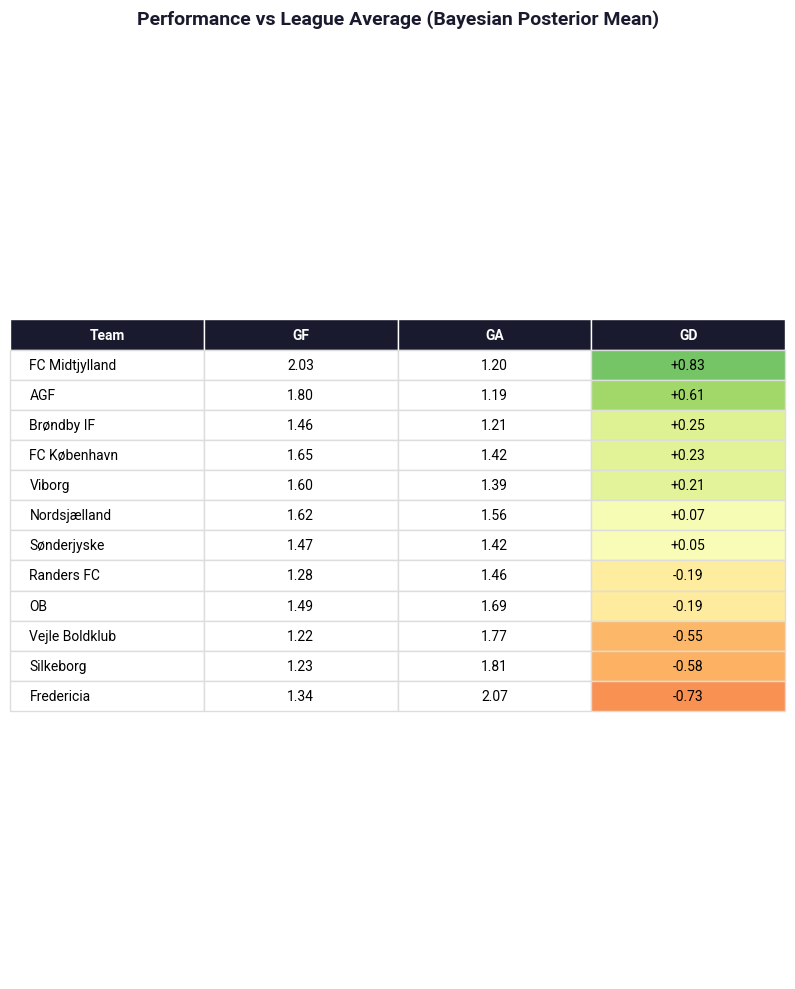

In [ ]:
# Heatmap table — styled like Elevenify
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.axis('off')

n_rows = len(ratings_df)
col_labels = ['Team', 'GF', 'GA', 'GD']

# Normaliser for GD column: green (+1.5) → red (−1.5)
gd_min, gd_max = -1.5, 1.5
norm = mcolors.Normalize(vmin=gd_min, vmax=gd_max)
cmap = plt.get_cmap('RdYlGn')

table_data = []
cell_colours = []

for _, row in ratings_df.iterrows():
    gd = row['goal_diff']
    gd_color = cmap(norm(np.clip(gd, gd_min, gd_max)))
    table_data.append([
        row['team'],
        f"{row['goals_for']:.2f}",
        f"{row['goals_against']:.2f}",
        f"{gd:+.2f}"
    ])
    cell_colours.append(['white', 'white', 'white', gd_color])

the_table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellColours=cell_colours,
    loc='center',
    cellLoc='center'
)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.5)

# Style header row
for j in range(len(col_labels)):
    the_table[0, j].set_facecolor('#1a1a2e')
    the_table[0, j].set_text_props(color='white', fontweight='bold')
    the_table[0, j].set_edgecolor('white')

# Left-align team name column
for i in range(1, n_rows + 1):
    the_table[i, 0].get_text().set_ha('left')
    for j in range(len(col_labels)):
        the_table[i, j].set_edgecolor('#dddddd')

ax.set_title('Performance vs League Average (Bayesian Posterior Mean)',
             fontsize=14, fontweight='bold', pad=20, color='#1a1a2e')

plt.tight_layout()
plt.savefig('performance_vs_league_avg.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 3. Viz 1 — Credible Interval Bar Charts

Attack and defence strength posterior distributions with 90% credible intervals. Teams with non-overlapping CIs from zero are confidently different from the league average.

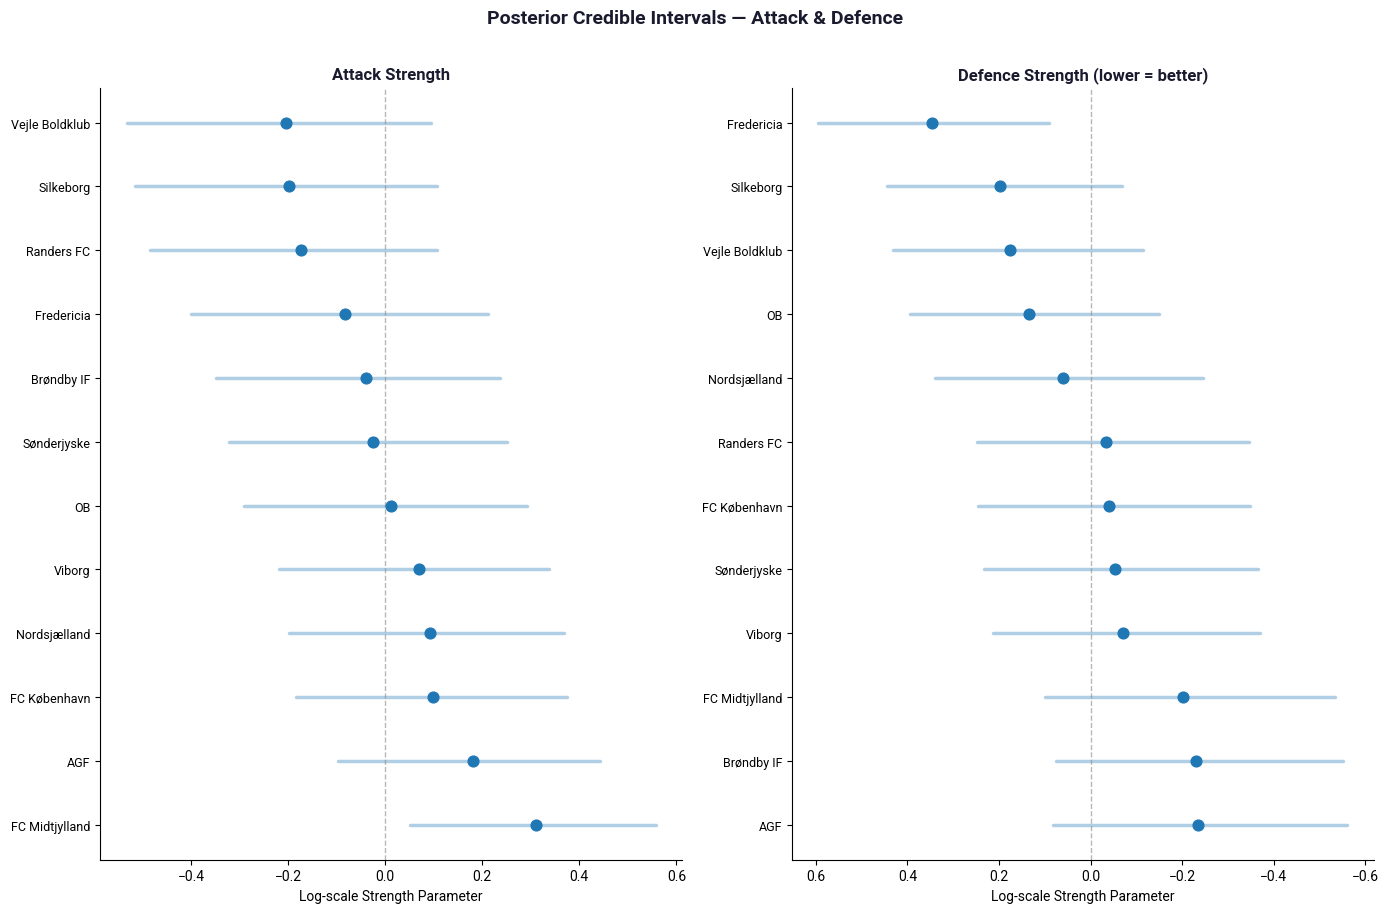

In [ ]:
# Extract percentiles per team
att_samples_all = trace.posterior['att_str'].values.reshape(-1, len(team_mapping))
def_samples_all = trace.posterior['def_str'].values.reshape(-1, len(team_mapping))

pct5, pct50, pct95 = 5, 50, 95

att_stats = {}
def_stats = {}

for team, idx in team_mapping.items():
    a = att_samples_all[:, idx]
    d = def_samples_all[:, idx]
    att_stats[team] = {
        'p5':   np.percentile(a, pct5),
        'p50':  np.percentile(a, pct50),
        'p95':  np.percentile(a, pct95),
    }
    def_stats[team] = {
        'p5':   np.percentile(d, pct5),
        'p50':  np.percentile(d, pct50),
        'p95':  np.percentile(d, pct95),
    }

# Sort attack best → worst (highest median first)
att_sorted = sorted(att_stats.items(), key=lambda x: x[1]['p50'], reverse=True)
# Sort defence best → worst (lowest median = best = last in reverse)
def_sorted = sorted(def_stats.items(), key=lambda x: x[1]['p50'], reverse=False)

fig, (ax_att, ax_def) = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor('white')

primary_blue = '#1f77b4'
ci_alpha     = 0.35

for ax, sorted_data, title, invert in [
    (ax_att, att_sorted, 'Attack Strength', False),
    (ax_def, def_sorted, 'Defence Strength (lower = better)', True),
]:
    ax.set_facecolor('white')
    teams_ordered = [t for t, _ in sorted_data]
    y_pos = np.arange(len(teams_ordered))

    for i, (team, s) in enumerate(sorted_data):
        # CI line
        ax.plot([s['p5'], s['p95']], [i, i], color=primary_blue, alpha=ci_alpha, linewidth=2.5, solid_capstyle='round')
        # Median dot
        ax.scatter(s['p50'], i, color=primary_blue, s=60, zorder=5)

    ax.axvline(0, color='#888888', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(teams_ordered, fontsize=9)
    ax.set_xlabel('Log-scale Strength Parameter', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.spines[['top', 'right']].set_visible(False)
    if invert:
        ax.invert_xaxis()

fig.suptitle('Posterior Credible Intervals — Attack & Defence', fontsize=14, fontweight='bold', y=1.01, color='#1a1a2e')
plt.tight_layout()
plt.savefig('ci_bar_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 4. Viz 2 — Luck vs Quality Table

For each played match, we compute expected points using Poisson distributions with the posterior mean xG. Teams with actual points > expected are 'Lucky'; those below are 'Unlucky'.

In [ ]:
def predict_match(home_team, away_team, trace, team_mapping):
    home_idx = team_mapping[home_team]
    away_idx = team_mapping[away_team]
    att_str  = trace.posterior['att_str'].values.reshape(-1, len(team_mapping))
    def_str  = trace.posterior['def_str'].values.reshape(-1, len(team_mapping))
    baseline = trace.posterior['baseline'].values.flatten()
    home_adv = trace.posterior['home_adv'].values.flatten()

    home_open_play_lambda = np.exp(baseline + home_adv + att_str[:, home_idx] + def_str[:, away_idx])
    away_open_play_lambda = np.exp(baseline + att_str[:, away_idx] + def_str[:, home_idx])

    home_total_lambda = home_open_play_lambda + BASELINE_HOME_PENS
    away_total_lambda = away_open_play_lambda + BASELINE_AWAY_PENS

    home_goals_pred = np.random.poisson(home_total_lambda)
    away_goals_pred = np.random.poisson(away_total_lambda)

    return {
        'home_goals_expected': np.mean(home_total_lambda),
        'away_goals_expected': np.mean(away_total_lambda),
        'home_win_prob':  np.mean(home_goals_pred > away_goals_pred),
        'draw_prob':      np.mean(home_goals_pred == away_goals_pred),
        'away_win_prob':  np.mean(home_goals_pred < away_goals_pred),
    }


def poisson_match_probs(hxg, axg, max_goals=10):
    p_hw = p_d = p_aw = 0.0
    for h in range(max_goals):
        for a in range(max_goals):
            p = scipy_poisson.pmf(h, hxg) * scipy_poisson.pmf(a, axg)
            if h > a:   p_hw += p
            elif h == a: p_d  += p
            else:        p_aw += p
    return p_hw, p_d, p_aw


# Only include played matches (those with non-null goals)
played = df_actual.dropna(subset=['home_goals', 'away_goals']).copy()

# Accumulate expected points per team
exp_pts = {t: 0.0 for t in team_mapping}
act_pts = {t: 0   for t in team_mapping}

print(f"Computing xPts for {len(played)} matches …")
for _, row in played.iterrows():
    ht, at = row['home_team'], row['away_team']
    hg, ag = int(row['home_goals']), int(row['away_goals'])

    pred = predict_match(ht, at, trace, team_mapping)
    hxg, axg = pred['home_goals_expected'], pred['away_goals_expected']
    phw, pd_, paw = poisson_match_probs(hxg, axg)

    exp_pts[ht] += 3 * phw + 1 * pd_
    exp_pts[at] += 3 * paw + 1 * pd_

    if hg > ag:   act_pts[ht] += 3
    elif hg == ag: act_pts[ht] += 1; act_pts[at] += 1
    else:          act_pts[at] += 3

luck_rows = []
for team in team_mapping:
    ap = act_pts[team]
    ep = exp_pts[team]
    luck_rows.append({'Team': team, 'Actual Pts': ap, 'Model xPts': round(ep, 1), 'Delta': round(ap - ep, 1)})

luck_df = (pd.DataFrame(luck_rows)
             .sort_values('Delta', ascending=False)
             .reset_index(drop=True))
luck_df['Verdict'] = luck_df['Delta'].apply(lambda d: 'Lucky' if d > 0.5 else ('Unlucky' if d < -0.5 else 'Fair'))
print(luck_df.to_string(index=False))


Computing xPts for 309 matches …


KeyError: 'Brentford'

NameError: name 'luck_df' is not defined

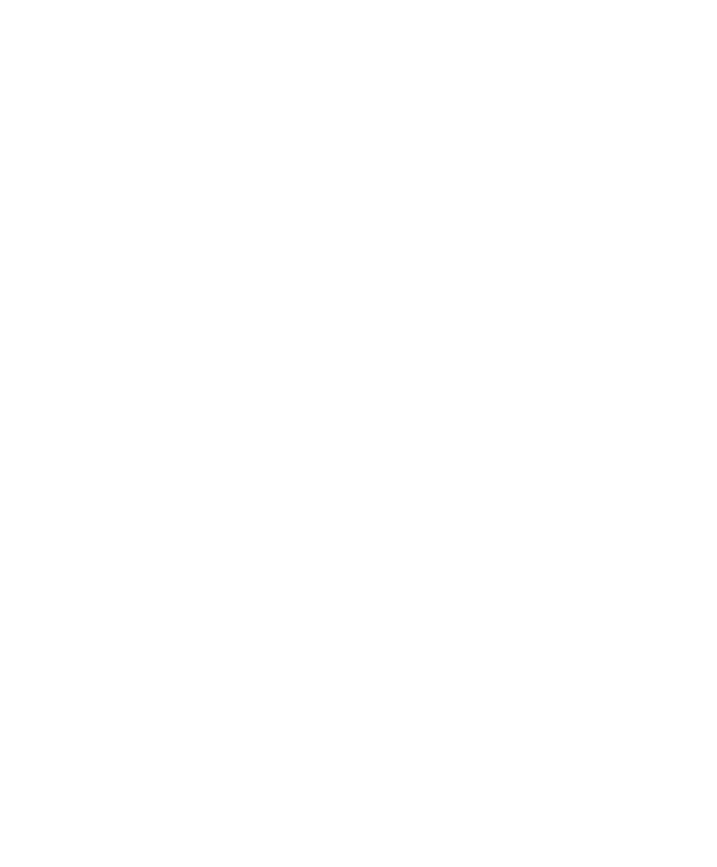

In [ ]:
# Render as a coloured matplotlib table
fig, ax = plt.subplots(figsize=(9, 11))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.axis('off')

cols = ['Team', 'Actual Pts', 'Model xPts', 'Δ Pts', 'Verdict']
table_data = []
cell_colours = []

delta_norm = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
delta_cmap = plt.get_cmap('RdYlGn')

for _, row in luck_df.iterrows():
    d = row['Delta']
    d_col = delta_cmap(delta_norm(np.clip(d, -10, 10)))
    table_data.append([row['Team'], int(row['Actual Pts']), row['Model xPts'], f"{d:+.1f}", row['Verdict']])
    cell_colours.append(['white', 'white', 'white', d_col, 'white'])

the_table = ax.table(
    cellText=table_data,
    colLabels=cols,
    cellColours=cell_colours,
    loc='center',
    cellLoc='center'
)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.55)

for j in range(len(cols)):
    the_table[0, j].set_facecolor('#1a1a2e')
    the_table[0, j].set_text_props(color='white', fontweight='bold')
    the_table[0, j].set_edgecolor('white')

for i in range(1, len(luck_df) + 1):
    the_table[i, 0].get_text().set_ha('left')
    for j in range(len(cols)):
        the_table[i, j].set_edgecolor('#dddddd')

ax.set_title('Luck vs Quality — Actual vs Model Expected Points', fontsize=13, fontweight='bold', pad=20, color='#1a1a2e')
plt.tight_layout()
plt.savefig('luck_vs_quality.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 5. Viz 3 — Position Probability Heatmap

> Note: `n_sims=500` for speed. Increase to `5000+` for publication-quality results.

In [ ]:
def precompute_expected_goals(trace, team_mapping, df_actual):
    teams = list(team_mapping.keys())
    actual_results = {}
    expected_goals = {}

    played_matches = {}
    if df_actual is not None and 'is_actual' in df_actual.columns:
        for _, row in df_actual[df_actual['is_actual']].iterrows():
            key = (row['home_team'], row['away_team'])
            played_matches[key] = row

    for home_team in teams:
        for away_team in teams:
            if home_team == away_team:
                continue
            key = (home_team, away_team)
            if key in played_matches:
                row = played_matches[key]
                hg = int(row['home_goals']) if pd.notna(row['home_goals']) else None
                ag = int(row['away_goals']) if pd.notna(row['away_goals']) else None
                if hg is None or ag is None:
                    pred = predict_match(home_team, away_team, trace, team_mapping)
                    expected_goals[key] = (pred['home_goals_expected'], pred['away_goals_expected'])
                else:
                    pred = predict_match(home_team, away_team, trace, team_mapping)
                    actual_results[key] = (hg, ag, pred['home_goals_expected'], pred['away_goals_expected'])
            else:
                pred = predict_match(home_team, away_team, trace, team_mapping)
                expected_goals[key] = (pred['home_goals_expected'], pred['away_goals_expected'])

    return actual_results, expected_goals


def _update_table(league_table, home_team, away_team, hg, ag, hxg, axg):
    ht = league_table[home_team]
    at = league_table[away_team]
    ht['played'] += 1;  at['played'] += 1
    ht['goals_for'] += hg;  ht['goals_against'] += ag
    at['goals_for'] += ag;  at['goals_against'] += hg
    ht['xg_for'] += hxg;   ht['xg_against'] += axg
    at['xg_for'] += axg;   at['xg_against'] += hxg
    if hg > ag:
        ht['wins'] += 1; ht['points'] += 3; at['losses'] += 1
    elif hg == ag:
        ht['draws'] += 1; ht['points'] += 1
        at['draws'] += 1; at['points'] += 1
    else:
        at['wins'] += 1; at['points'] += 3; ht['losses'] += 1


def simulate_full_season_fast(actual_results, expected_goals, teams):
    league_table = {team: {
        'played': 0, 'wins': 0, 'draws': 0, 'losses': 0,
        'goals_for': 0, 'goals_against': 0, 'goal_difference': 0,
        'xg_for': 0.0, 'xg_against': 0.0, 'xg_difference': 0.0,
        'points': 0
    } for team in teams}

    unplayed_keys = list(expected_goals.keys())
    if unplayed_keys:
        hxg_arr = np.array([expected_goals[k][0] for k in unplayed_keys])
        axg_arr = np.array([expected_goals[k][1] for k in unplayed_keys])
        home_goals_sim = np.random.poisson(hxg_arr)
        away_goals_sim = np.random.poisson(axg_arr)

    for (home_team, away_team), (hg, ag, hxg, axg) in actual_results.items():
        _update_table(league_table, home_team, away_team, hg, ag, hxg, axg)

    for i, (home_team, away_team) in enumerate(unplayed_keys):
        hxg, axg = expected_goals[(home_team, away_team)]
        _update_table(league_table, home_team, away_team,
                      home_goals_sim[i], away_goals_sim[i], hxg, axg)

    for team in teams:
        t = league_table[team]
        t['goal_difference'] = t['goals_for'] - t['goals_against']
        t['xg_difference']   = t['xg_for']    - t['xg_against']

    return league_table


def run_multiple_seasons(n_simulations, trace, team_mapping, df_actual):
    teams  = list(team_mapping.keys())
    n_teams = len(teams)

    actual_results, expected_goals = precompute_expected_goals(trace, team_mapping, df_actual)

    acc_points        = np.zeros(n_teams, dtype=np.float64)
    acc_wins          = np.zeros(n_teams, dtype=np.float64)
    acc_draws         = np.zeros(n_teams, dtype=np.float64)
    acc_losses        = np.zeros(n_teams, dtype=np.float64)
    acc_goals_for     = np.zeros(n_teams, dtype=np.float64)
    acc_goals_against = np.zeros(n_teams, dtype=np.float64)
    acc_xg_for        = np.zeros(n_teams, dtype=np.float64)
    acc_xg_against    = np.zeros(n_teams, dtype=np.float64)
    acc_positions     = np.zeros(n_teams, dtype=np.float64)
    title_counts      = np.zeros(n_teams, dtype=np.int32)
    top5_counts       = np.zeros(n_teams, dtype=np.int32)
    relegation_counts = np.zeros(n_teams, dtype=np.int32)
    pos_freq          = np.zeros((n_teams, n_teams), dtype=np.int32)

    print(f"Running {n_simulations:,} simulations...")

    for sim in range(n_simulations):
        if sim % 100 == 0 and sim > 0:
            print(f"  {sim:,} / {n_simulations:,} done...")

        league_table = simulate_full_season_fast(actual_results, expected_goals, teams)

        pts   = np.array([league_table[t]['points']         for t in teams])
        gd    = np.array([league_table[t]['goal_difference'] for t in teams])
        gf    = np.array([league_table[t]['goals_for']       for t in teams])
        order = np.lexsort((gf, gd, pts))[::-1]

        positions = np.empty(n_teams, dtype=np.int32)
        positions[order] = np.arange(1, n_teams + 1)

        acc_points        += pts
        acc_wins          += [league_table[t]['wins']          for t in teams]
        acc_draws         += [league_table[t]['draws']         for t in teams]
        acc_losses        += [league_table[t]['losses']        for t in teams]
        acc_goals_for     += [league_table[t]['goals_for']     for t in teams]
        acc_goals_against += [league_table[t]['goals_against'] for t in teams]
        acc_xg_for        += [league_table[t]['xg_for']        for t in teams]
        acc_xg_against    += [league_table[t]['xg_against']    for t in teams]
        acc_positions     += positions
        title_counts      += (positions == 1)
        top5_counts        += (positions <= 5)
        relegation_counts  += (positions >= 18)
        pos_freq[np.arange(n_teams), positions - 1] += 1

    avg_df = pd.DataFrame({
        'team':              teams,
        'avg_points':        acc_points        / n_simulations,
        'avg_wins':          acc_wins          / n_simulations,
        'avg_draws':         acc_draws         / n_simulations,
        'avg_losses':        acc_losses        / n_simulations,
        'avg_goals_for':     acc_goals_for     / n_simulations,
        'avg_goals_against': acc_goals_against / n_simulations,
        'avg_xg_for':        acc_xg_for        / n_simulations,
        'avg_xg_against':    acc_xg_against    / n_simulations,
        'avg_position':      acc_positions     / n_simulations,
        'title_pct':         np.round(title_counts      / n_simulations * 100, 1),
        'top5_pct':          np.round(top5_counts        / n_simulations * 100, 1),
        'relegation_pct':    np.round(relegation_counts  / n_simulations * 100, 1),
    })
    avg_df['avg_goal_difference'] = avg_df['avg_goals_for'] - avg_df['avg_goals_against']
    avg_df['avg_xg_difference']   = avg_df['avg_xg_for']    - avg_df['avg_xg_against']
    avg_df = avg_df.sort_values(
        ['avg_points', 'avg_goal_difference', 'avg_goals_for'],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    avg_df.index = avg_df.index + 1

    position_counts = {team: list(pos_freq[i]) for i, team in enumerate(teams)}
    return avg_df, position_counts


# Run simulations — increase n_sims for publication quality
n_sims = 500
avg_table, position_freq = run_multiple_seasons(n_sims, trace, team_mapping, df_actual)
print(avg_table[['team', 'avg_points', 'avg_position', 'title_pct', 'relegation_pct']].to_string(index=False))


In [ ]:
# Build probability matrix for heatmap
teams_by_avg_pos = avg_table.sort_values('avg_position')['team'].tolist()
n_teams_h = len(teams_by_avg_pos)
n_positions = n_teams_h

prob_matrix = np.zeros((n_teams_h, n_positions))
for i, team in enumerate(teams_by_avg_pos):
    counts = position_freq[team]  # list of length n_teams
    total  = sum(counts)
    if total > 0:
        prob_matrix[i] = [c / total * 100 for c in counts]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

im = ax.imshow(prob_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(n_positions))
ax.set_xticklabels([str(p + 1) for p in range(n_positions)], fontsize=9)
ax.set_yticks(range(n_teams_h))
ax.set_yticklabels(teams_by_avg_pos, fontsize=9)

ax.set_xlabel('Final League Position', fontsize=11)
ax.set_ylabel('Team (sorted by avg position)', fontsize=11)
ax.set_title(f'Season Finish Position Probabilities ({n_sims:,} simulations)', fontsize=13, fontweight='bold', color='#1a1a2e')

# Annotate cells with probability > 15%
for i in range(n_teams_h):
    for j in range(n_positions):
        val = prob_matrix[i, j]
        if val > 15:
            text_color = 'white' if val > 60 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7.5,
                    color=text_color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Probability (%)', fontsize=10)

plt.tight_layout()
plt.savefig('position_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 6. Viz 4 — Uncertainty-Adjusted Power Rankings

For each team, we compute `P(team scores more goals than a random league opponent)` using Poisson CDF with posterior mean lambdas. This reframes 'who is best' as 'who do we most confidently believe beats the average opponent'.

In [ ]:
from scipy.stats import poisson as sp_poisson

def p_team_beats_opponent(lam_i, lam_j, max_goals=15):
    """P(goals_i > goals_j) under independent Poisson(lam_i), Poisson(lam_j)."""
    p_win = 0.0
    for h in range(max_goals):
        for a in range(h):           # a < h  =>  home wins
            p_win += sp_poisson.pmf(h, lam_i) * sp_poisson.pmf(a, lam_j)
    return p_win


# Posterior mean lambdas for each team as neutral (average of home/away)
baseline_mean  = float(trace.posterior['baseline'].values.mean())
home_adv_mean  = float(trace.posterior['home_adv'].values.mean())
att_means      = trace.posterior['att_str'].values.reshape(-1, len(team_mapping)).mean(axis=0)
def_means      = trace.posterior['def_str'].values.reshape(-1, len(team_mapping)).mean(axis=0)

team_win_probs = {}
for team_i, idx_i in team_mapping.items():
    p_beat_opp = []
    for team_j, idx_j in team_mapping.items():
        if team_i == team_j:
            continue
        # neutral venue: average of home and away lambda
        lam_ij_home = np.exp(baseline_mean + home_adv_mean + att_means[idx_i] + def_means[idx_j]) + BASELINE_HOME_PENS
        lam_ij_away = np.exp(baseline_mean + att_means[idx_i] + def_means[idx_j]) + BASELINE_AWAY_PENS
        lam_i_neutral = (lam_ij_home + lam_ij_away) / 2

        lam_ji_home = np.exp(baseline_mean + home_adv_mean + att_means[idx_j] + def_means[idx_i]) + BASELINE_HOME_PENS
        lam_ji_away = np.exp(baseline_mean + att_means[idx_j] + def_means[idx_i]) + BASELINE_AWAY_PENS
        lam_j_neutral = (lam_ji_home + lam_ji_away) / 2

        p_beat_opp.append(p_team_beats_opponent(lam_i_neutral, lam_j_neutral))

    team_win_probs[team_i] = np.mean(p_beat_opp)

win_prob_df = (pd.DataFrame.from_dict(team_win_probs, orient='index', columns=['win_prob'])
               .sort_values('win_prob', ascending=True)
               .reset_index()
               .rename(columns={'index': 'team'}))

print(win_prob_df.to_string(index=False))


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = ['#d62728' if p < 0.5 else '#1f77b4' for p in win_prob_df['win_prob']]

ax.hlines(win_prob_df['team'], 0.5, win_prob_df['win_prob'],
          colors=['#cccccc'] * len(win_prob_df), linewidth=1.5)
ax.scatter(win_prob_df['win_prob'], win_prob_df['team'], color=colors, s=80, zorder=5)

ax.axvline(0.5, color='#444444', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('P(Beats Average Opponent)', fontsize=11)
ax.set_title('Uncertainty-Adjusted Power Rankings
P(team scores more goals than random league opponent)',
             fontsize=12, fontweight='bold', color='#1a1a2e')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

above = mpatches.Patch(color='#1f77b4', label='P > 50% (above average)')
below = mpatches.Patch(color='#d62728', label='P < 50% (below average)')
ax.legend(handles=[above, below], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('uncertainty_power_rankings.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 7. Viz 5 — Attack / Defence Quadrant Scatter with CI Ellipses

Each ellipse represents a 90% credible region of (att_str, def_str) for a team. The crosshairs at (0, 0) represent the league average.

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=1.645, **kwargs):
    """
    Draw a confidence ellipse from 2D sample arrays x and y.
    n_std=1.645 gives approximately 90% CI for bivariate normal.
    """
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])

    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)

    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)

    transf = (transforms.Affine2D()
              .rotate_deg(45)
              .scale(scale_x, scale_y)
              .translate(mean_x, mean_y))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)


att_samples_all = trace.posterior['att_str'].values.reshape(-1, len(team_mapping))
def_samples_all = trace.posterior['def_str'].values.reshape(-1, len(team_mapping))

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Quadrant colors: good att + good def = top-right perspective (high att, low def)
# x = att (higher = better), y = def (lower = better defensively)
# Quadrant logic based on (0, 0) crosshairs:
#   att > 0, def < 0  → strong attack, strong defence (top-right) = good overall
#   att > 0, def > 0  → strong attack, weak defence
#   att < 0, def < 0  → weak attack, strong defence
#   att < 0, def > 0  → weak attack, weak defence

for team, idx in team_mapping.items():
    att_s = att_samples_all[:, idx]
    def_s = def_samples_all[:, idx]
    att_mu = att_s.mean()
    def_mu = def_s.mean()

    if att_mu >= 0 and def_mu <= 0:
        color = '#2ca02c'   # good attack + good defence
    elif att_mu >= 0 and def_mu > 0:
        color = '#ff7f0e'   # good attack + bad defence
    elif att_mu < 0 and def_mu <= 0:
        color = '#1f77b4'   # bad attack + good defence
    else:
        color = '#d62728'   # bad attack + bad defence

    confidence_ellipse(att_s, def_s, ax,
                       n_std=1.645,
                       facecolor=color, alpha=0.18,
                       edgecolor=color, linewidth=1.2)
    ax.scatter(att_mu, def_mu, color=color, s=40, zorder=5)
    ax.annotate(team, (att_mu, def_mu),
                textcoords='offset points', xytext=(5, 4),
                fontsize=7.5, color=color, fontweight='bold')

# Crosshairs at league average
ax.axhline(0, color='#555555', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(0, color='#555555', linewidth=1, linestyle='--', alpha=0.6)

ax.set_xlabel('Attack Strength (log-scale, higher = better)', fontsize=11)
ax.set_ylabel('Defence Strength (log-scale, lower = better)', fontsize=11)
ax.invert_yaxis()   # lower def_str = better, put at top
ax.set_title('Attack vs Defence — 90% Posterior Credible Ellipses', fontsize=13, fontweight='bold', color='#1a1a2e')
ax.spines[['top', 'right']].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color='#2ca02c', label='Good attack + Good defence'),
    mpatches.Patch(color='#ff7f0e', label='Good attack + Weak defence'),
    mpatches.Patch(color='#1f77b4', label='Weak attack + Good defence'),
    mpatches.Patch(color='#d62728', label='Weak attack + Weak defence'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('att_def_quadrant.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
